DATA VISUALIZATION :
Here we need to visualize the co2 emission plot.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Cleaned_co2_emissions.csv")
df

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,...,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,Afghanistan,1990,14.7237,0.0557,False,686.0000,0.0,11.807483,63.1152,-2388.8030,...,319.1763,0.0,0.0,141.0963,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167
1,Afghanistan,1991,14.7237,0.0557,False,678.1600,0.0,11.712073,61.2125,-2388.8030,...,342.3079,0.0,0.0,141.0963,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667
2,Afghanistan,1992,14.7237,0.0557,False,686.0000,0.0,11.712073,53.3170,-2388.8030,...,349.1224,0.0,0.0,141.0963,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583
3,Afghanistan,1993,14.7237,0.0557,False,686.0000,0.0,11.712073,54.3617,-2388.8030,...,352.2947,0.0,0.0,141.0963,11858090.0,3237009.0,7003641.0,7000119.0,2368.470529,0.101917
4,Afghanistan,1994,14.7237,0.0557,False,705.6000,0.0,11.712073,53.9874,-2388.8030,...,367.6784,0.0,0.0,141.0963,12690115.0,3482604.0,7733458.0,7722096.0,2500.768729,0.372250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6960,Zimbabwe,2016,1190.0089,232.5068,False,7.4088,0.0,75.000000,251.1465,76500.2982,...,282.5994,0.0,0.0,417.3150,10934468.0,5215894.0,6796658.0,7656047.0,98491.026347,1.120250
6961,Zimbabwe,2017,1431.1407,131.1324,False,7.9458,0.0,67.000000,255.7975,76500.2982,...,255.5900,0.0,0.0,398.1644,11201138.0,5328766.0,6940631.0,7810471.0,97159.311553,0.046500
6962,Zimbabwe,2018,1557.5830,221.6222,False,8.1399,0.0,66.000000,327.0897,76500.2982,...,257.2735,0.0,0.0,465.7735,11465748.0,5447513.0,7086002.0,7966181.0,97668.308205,0.516333
6963,Zimbabwe,2019,1591.6049,171.0262,False,7.8322,0.0,73.000000,290.1893,76500.2982,...,267.5224,0.0,0.0,444.2335,11725970.0,5571525.0,7231989.0,8122618.0,98988.062799,0.985667


HISTPLOTS

<Axes: ylabel='Frequency'>

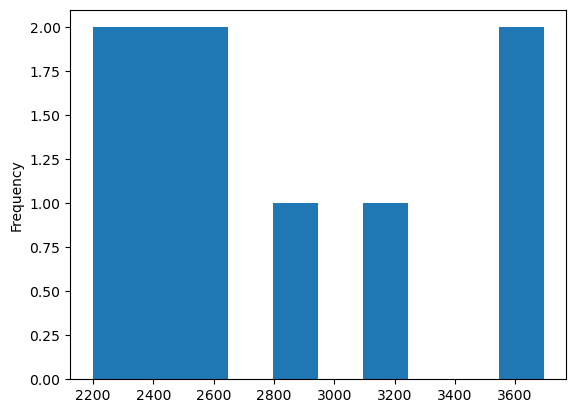

In [4]:
df['total_emission'].head(10).plot(kind='hist',bins=10)

<Axes: ylabel='Frequency'>

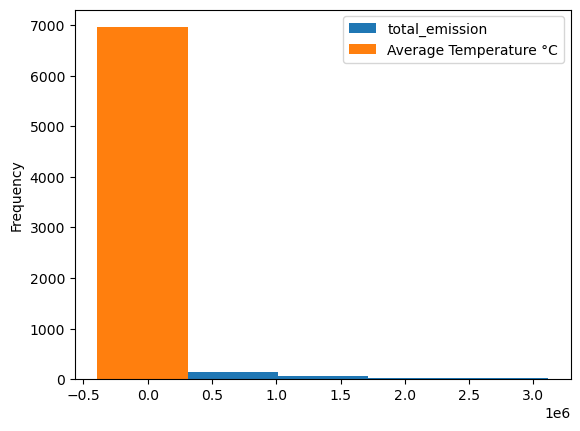

In [5]:
df[['total_emission','Average Temperature °C']].astype(float).plot(
                        kind='hist',
                        bins=5,
                        )

PIEPLOT

In [6]:
#co2 emission distribution by  different sectors
fires=df[['Savanna fires','Forest fires']].mean().sum()
crops=df[['Pesticides Manufacturing','Rice Cultivation']].mean().sum()
manure=df[['Manure applied to Soils','Manure Management']].mean().sum()
pesticides=df['Pesticides Manufacturing'].mean()
fires,crops,manure,pesticides

(2090.1430459511844, 4593.085066410272, 2814.0021523330943, 333.41839297406244)

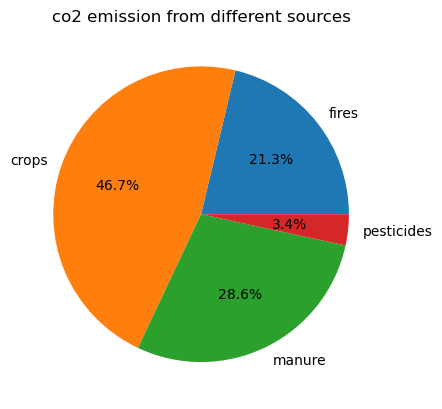

In [7]:
pdata = pd.Series([fires,crops,manure,pesticides],index=['fires','crops','manure','pesticides'])
pdata.plot(kind='pie',autopct='%1.1f%%',title='co2 emission from different sources')
plt.show()

BARPLOT

In [8]:
# avg temperature for each area 
country_emissions=df.groupby('Area')['Average Temperature °C'].mean().sort_values(ascending=False)
print(country_emissions)

Area
Luxembourg                          1.545921
Serbia                              1.526917
Estonia                             1.522491
Belarus                             1.495724
Belgium                             1.485413
                                      ...   
Zimbabwe                            0.320452
Yugoslav SFR                        0.287542
Marshall Islands                    0.265972
Cook Islands                        0.247414
Micronesia (Federated States of)    0.231883
Name: Average Temperature °C, Length: 236, dtype: float64


In [9]:
# top 10 countries with high avg temp
top10=country_emissions.head(10)
top10

Area
Luxembourg            1.545921
Serbia                1.526917
Estonia               1.522491
Belarus               1.495724
Belgium               1.485413
Latvia                1.484609
Russian Federation    1.483595
Montenegro            1.458567
Finland               1.452164
Lithuania             1.439224
Name: Average Temperature °C, dtype: float64

Above bar plot is top 10 countries with high avg temp.

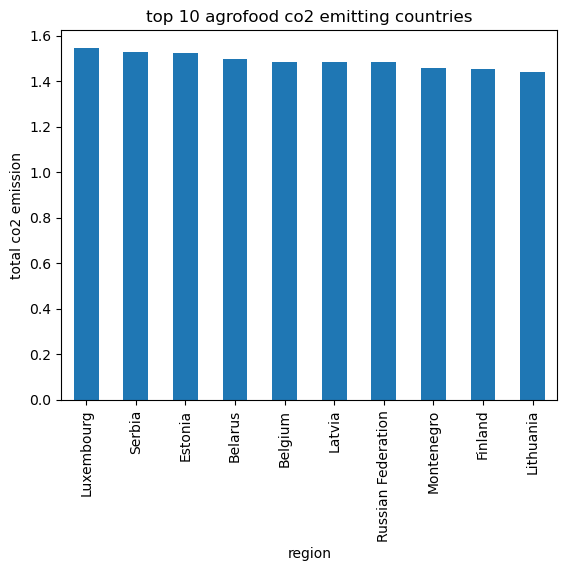

In [10]:
top10.plot(kind='bar',
           title="top 10 agrofood co2 emitting countries",
           xlabel='region',ylabel='total co2 emission')

plt.show()

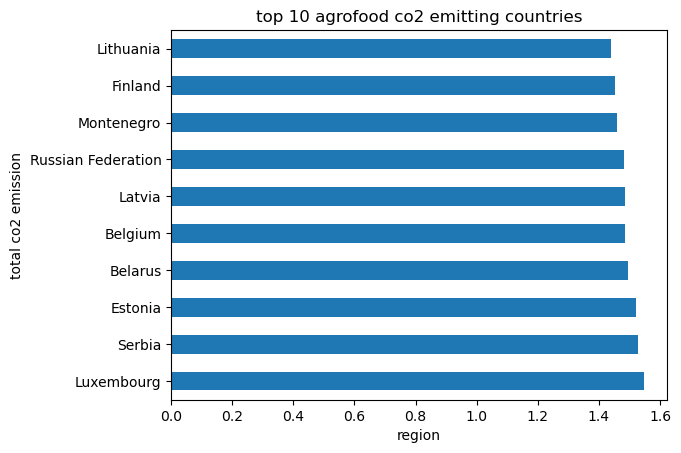

In [11]:
top10.plot(kind='barh',
           title="top 10 agrofood co2 emitting countries",
           xlabel='region',ylabel='total co2 emission')

plt.show()

<Axes: title={'center': 'co2 emission over years'}, xlabel='Year', ylabel='Average Temperature °C'>

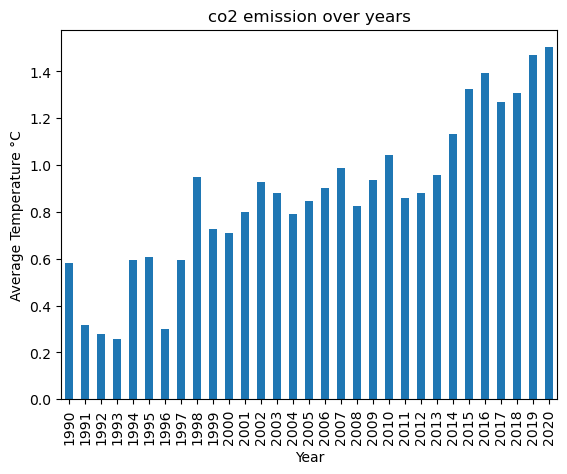

In [12]:
yearly_avgtemp=df.groupby('Year')['Average Temperature °C'].mean()
yearly_avgtemp.plot(
    kind='bar',
    xlabel='Year',
    ylabel='Average Temperature °C',
    title='co2 emission over years'
)

SCATTER plot of total emission vs avg temp.

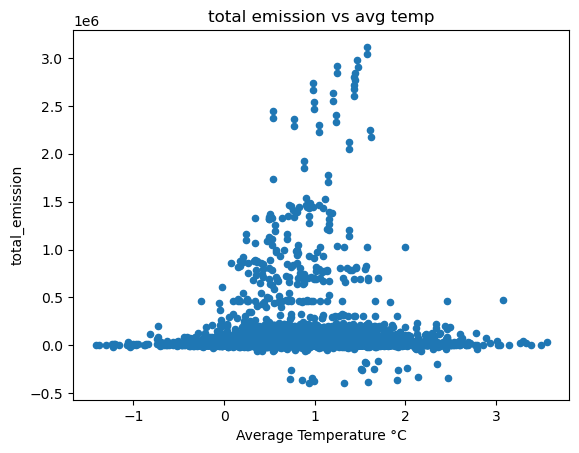

In [13]:
# plt.scatter(df['total_emission'],df['Average Temperature °C'])
df[['total_emission','Average Temperature °C']].astype(float).plot(
    kind='scatter',
    y='total_emission',
    x='Average Temperature °C',
    title='total emission vs avg temp'
)
plt.show()

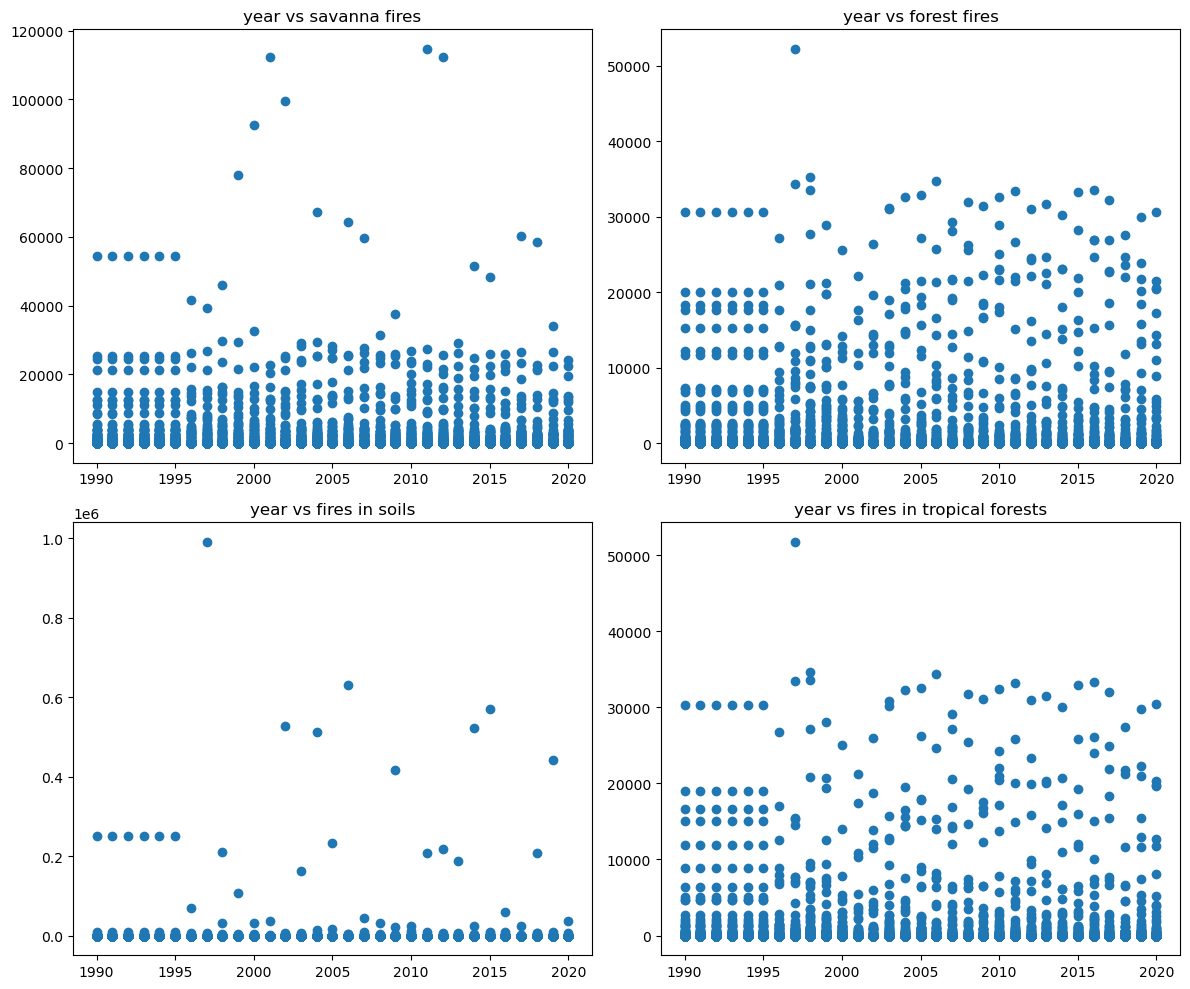

In [14]:
fig ,ax= plt.subplots(2,2,figsize=(12,10))

ax[0,0].scatter(df['Year'],df['Savanna fires'])
ax[0,0].set_title("year vs savanna fires")
ax[0,1].scatter(df['Year'],df['Forest fires'])
ax[0,1].set_title("year vs forest fires")
ax[1,0].scatter(df['Year'],df['Fires in organic soils'])
ax[1,0].set_title("year vs fires in soils")
ax[1,1].scatter(df['Year'],df['Fires in humid tropical forests'])
ax[1,1].set_title("year vs fires in tropical forests")
plt.tight_layout()

plt.show()

LINEPLOT

In [15]:
#emission trend over time (global)
global_trend=df.groupby('Year')['total_emission'].mean()

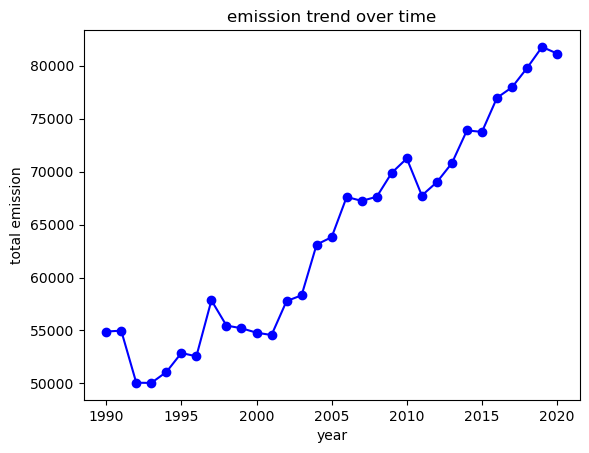

In [16]:
global_trend.plot(kind='line',
                marker='o',
                color='blue',
                xlabel='year',
                ylabel='total emission',
                title='emission trend over time')

plt.show()

<Axes: title={'center': 'savanna fires vs year'}, xlabel='year', ylabel='savanna fires'>

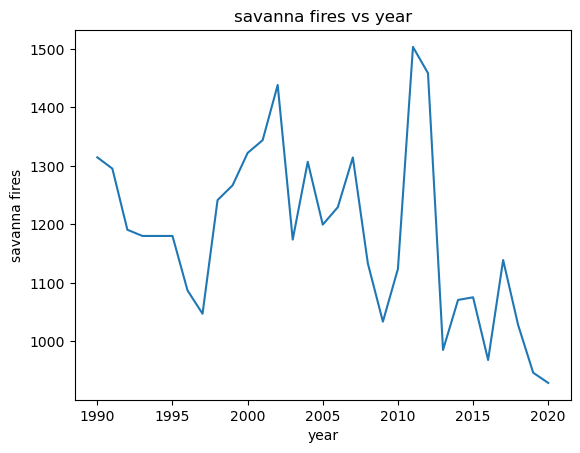

In [17]:
df.groupby('Year')['Savanna fires'].mean().plot(kind='line',xlabel='year',ylabel="savanna fires",title="savanna fires vs year")

<Axes: title={'center': 'forest fires vs year'}, xlabel='year', ylabel='forest fires'>

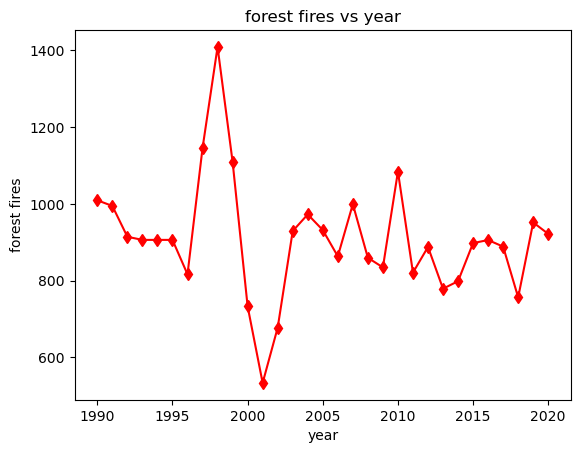

In [18]:
df.groupby('Year')['Forest fires'].mean().plot(kind='line',xlabel='year',ylabel="forest fires",title="forest fires vs year",marker='d',color='red')

AREAPLOT

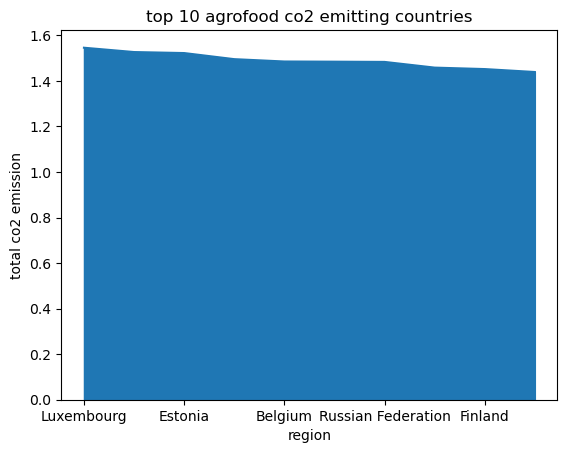

In [19]:
top10.plot(kind='area',
           title="top 10 agrofood co2 emitting countries",
           xlabel='region',ylabel='total co2 emission')

plt.show()

BOXPLOT

In [20]:
df.columns

Index(['Area', 'Year', 'Savanna fires', 'Forest fires', 'Crop Residues',
       'Rice Cultivation', 'Drained organic soils (CO2)',
       'Pesticides Manufacturing', 'Food Transport', 'Forestland',
       'Net Forest conversion', 'Food Household Consumption', 'Food Retail',
       'On-farm Electricity Use', 'Food Packaging',
       'Agrifood Systems Waste Disposal', 'Food Processing',
       'Fertilizers Manufacturing', 'IPPU', 'Manure applied to Soils',
       'Manure left on Pasture', 'Manure Management', 'Fires in organic soils',
       'Fires in humid tropical forests', 'On-farm energy use',
       'Rural population', 'Urban population', 'Total Population - Male',
       'Total Population - Female', 'total_emission',
       'Average Temperature °C'],
      dtype='object')

<Axes: >

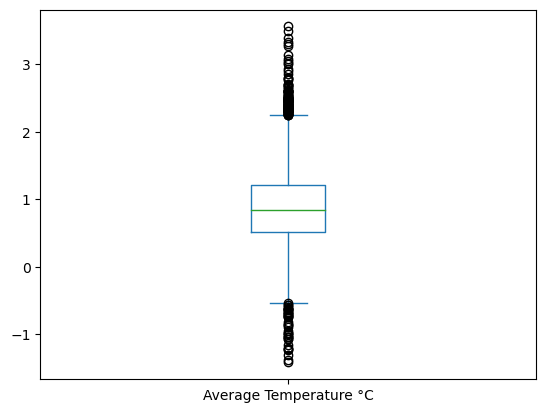

In [21]:
df['Average Temperature °C'].plot(kind='box')
#as all the points lie in the outliers ..it means they are the extreme high and low values ... that means all countries have the different temperatures of extreme  values.

<Axes: >

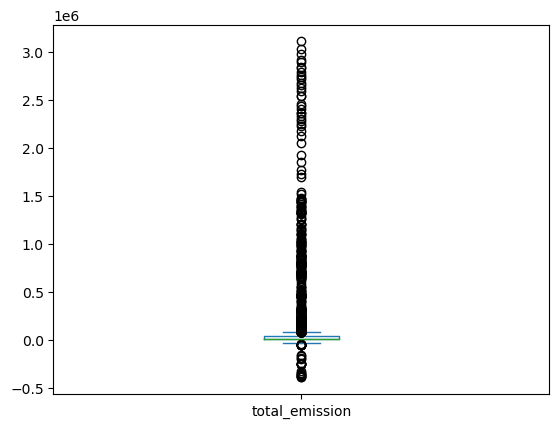

In [22]:
df['total_emission'].plot(kind='box')

MAP

In [23]:
import folium

print('Folium installed and imported!')

Folium installed and imported!


In [24]:
world_map = folium.Map()
world_map

In [25]:
df['Area'].nunique()

236

In [26]:
data = df[['Area', 'Average Temperature °C']]
m = folium.Map(location=[20,0], zoom_start=2)

folium.Choropleth(
    geo_data="world_countries.json",   # GeoJSON file of world countries
    data=data,
    columns=["Area", "Average Temperature °C"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Average Temperature °C"
).add_to(m)

# Save map
m.save("avg_temperature_map.html")

In [27]:
import pandas as pd
import plotly.express as px
# Create choropleth map
fig = px.choropleth(
    df,
    locations="Area",
    locationmode="country names",
    color="Area",
    hover_name="Area",
    color_continuous_scale="YlOrRd",
    title="Countries"
)
import pandas as pd
import plotly.express as px
# Create choropleth map
fig = px.choropleth(
    df,
    locations="Area",
    locationmode="country names",
    color="Area",
    hover_name="Area",
    color_continuous_scale="YlOrRd",
    title="Countries"
)

fig.show()

Correlation Heatmaps

Correlation is used to show the relationships between all the variables visually. 
If it has RED colour:strong positive relationship,
BLUE colour: Strong negative relationship,
WHITE colour: no relationship.

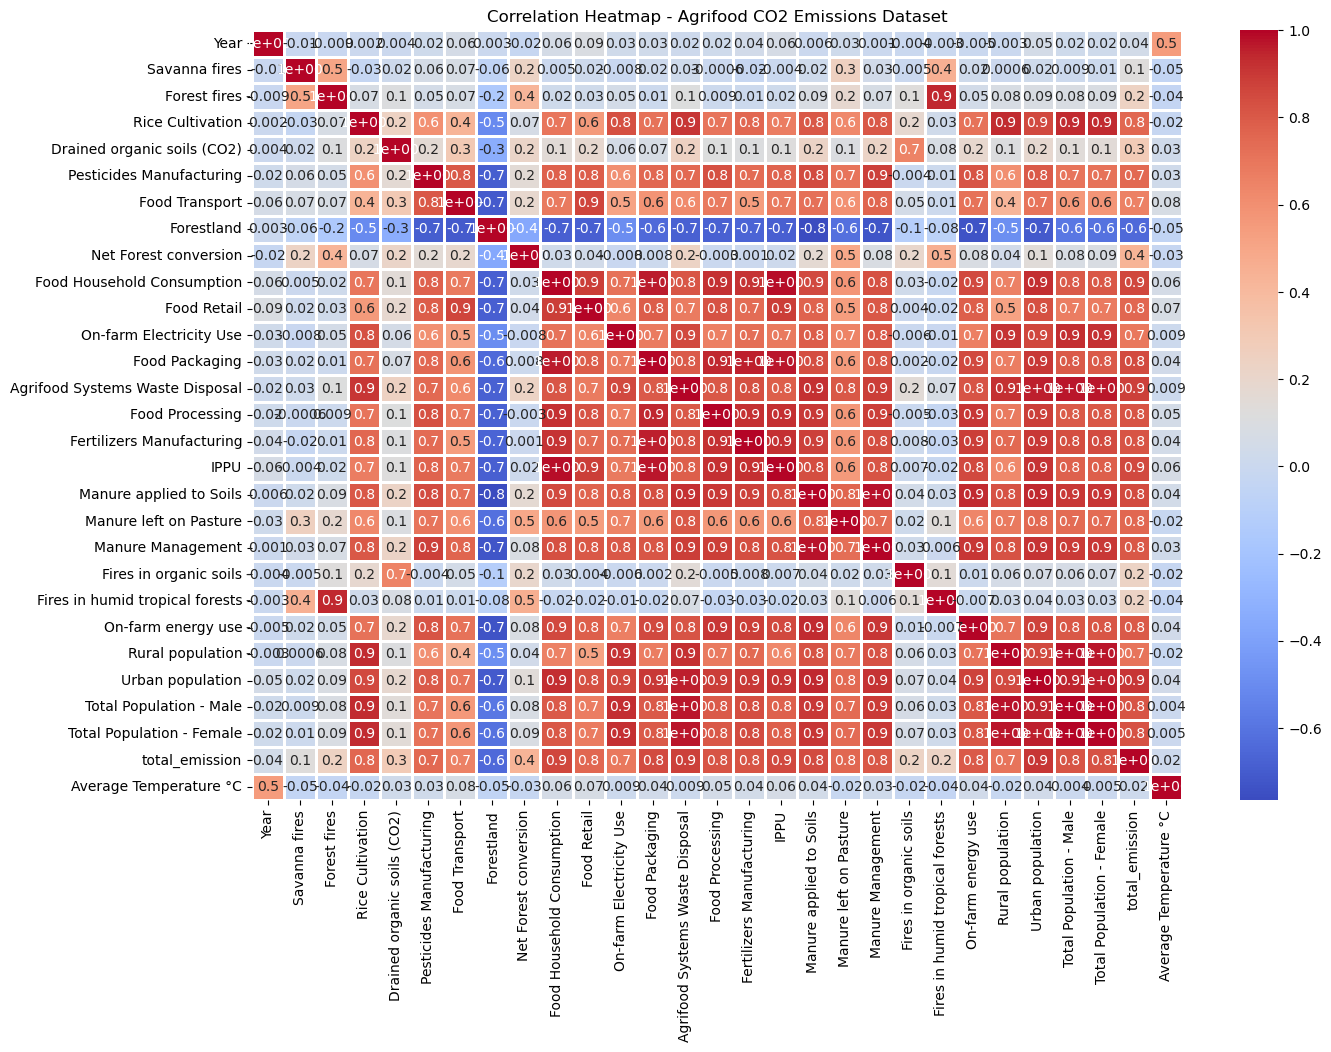

In [28]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

#Compute correlation matrix
corr_matrix = numeric_df.corr()

#Plot heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(
    corr_matrix,
    annot=True,        
    fmt=".1",         
    cmap="coolwarm",   
    linewidths=1
)

plt.title("Correlation Heatmap - Agrifood CO2 Emissions Dataset")
plt.show()

In [31]:
df.columns

Index(['Area', 'Year', 'Savanna fires', 'Forest fires', 'Crop Residues',
       'Rice Cultivation', 'Drained organic soils (CO2)',
       'Pesticides Manufacturing', 'Food Transport', 'Forestland',
       'Net Forest conversion', 'Food Household Consumption', 'Food Retail',
       'On-farm Electricity Use', 'Food Packaging',
       'Agrifood Systems Waste Disposal', 'Food Processing',
       'Fertilizers Manufacturing', 'IPPU', 'Manure applied to Soils',
       'Manure left on Pasture', 'Manure Management', 'Fires in organic soils',
       'Fires in humid tropical forests', 'On-farm energy use',
       'Rural population', 'Urban population', 'Total Population - Male',
       'Total Population - Female', 'total_emission',
       'Average Temperature °C'],
      dtype='object')

In [ ]:
sns.pairplot(df[['Year', 'Savanna fires', 'Forest fires', 'Food Transport','total_emission','Average Temperature °C']].select_dtypes(include='number'))
plt.show()